In [82]:
import os
import math
from typing import List, Dict, Tuple, Optional
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
from scipy import optimize
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 200)
plt.style.use('seaborn-v0_8')

RISK_FREE_RATE = 0.04 
CACHE_DIR = './.cache'
os.makedirs(CACHE_DIR, exist_ok=True)

In [59]:
def cache_load(path: str):
    if os.path.exists(path):
        return joblib.load(path)
    return None

def cache_save(obj, path: str):
    joblib.dump(obj, path)

def to_annualized_return(daily_ret: np.ndarray, periods_per_year: int = 252) -> float:
    mean = np.nanmean(daily_ret)
    return (1 + mean) ** periods_per_year - 1

def to_annualized_vol(daily_ret: np.ndarray, periods_per_year: int = 252) -> float:
    return np.nanstd(daily_ret) * math.sqrt(periods_per_year)

def date_n_days_ago(days: int) -> datetime:
    return datetime.utcnow() - timedelta(days=days)

In [60]:
def load_tickers_from_csv(path: str, column: str = 'ticker') -> List[str]:
    df = pd.read_csv(path)
    return df[column].dropna().astype(str).str.upper().tolist()

DEFAULT_TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN"]  

def download_price_history(tickers: List[str], start: str = None, end: str = None, interval: str = '1d') -> pd.DataFrame:
    if start is None:
        start = (datetime.utcnow() - pd.DateOffset(years=3)).strftime('%Y-%m-%d')  # 3 años por defecto
    if end is None:
        end = datetime.utcnow().strftime('%Y-%m-%d')
    cache_path = os.path.join(CACHE_DIR, f"prices_{start}_{end}_{interval}.pkl")
    cached = cache_load(cache_path)
    if cached is not None:
        return cached
    data = yf.download(tickers, start=start, end=end, interval=interval, group_by='ticker', auto_adjust=True, threads=True)
    if isinstance(data.columns, pd.MultiIndex):
        adj = pd.DataFrame({t: data[t]['Close'] for t in tickers if (t in data.columns.levels[0])})
    else:
        adj = data['Close'] if 'Close' in data.columns else data
    cache_save(adj, cache_path)
    return adj

In [61]:
def fetch_fundamentals(ticker: str) -> Dict:
    try:
        t = yf.Ticker(ticker)
        info = t.info or {}
        return info
    except Exception as e:
        print(f"[fetch_fundamentals] Error {ticker}: {e}")
        return {}

def compute_ratios_from_info(info: Dict) -> Dict[str, Optional[float]]:
    def safe_get(d, *keys):
        for k in keys:
            if k in d and d[k] is not None:
                return d[k]
        return None

    pe = safe_get(info, 'trailingPE', 'forwardPE')
    pb = safe_get(info, 'priceToBook')
    roe = safe_get(info, 'returnOnEquity')
    debt_eq = safe_get(info, 'debtToEquity', 'totalDebt', 'longTermDebt')
    current_ratio = safe_get(info, 'currentRatio')
    ebitda_margin = safe_get(info, 'ebitdaMargins', 'ebitdaMargins')

    def to_float(x):
        try:
            return float(x)
        except:
            return None

    return {
        'PE': to_float(pe),
        'PB': to_float(pb),
        'ROE': to_float(roe),
        'DebtToEquity': to_float(debt_eq),
        'CurrentRatio': to_float(current_ratio),
        'EBITDA_Margin': to_float(ebitda_margin)
    }

def score_asset_by_ratios(ratios: Dict[str, Optional[float]], weights: Dict[str, float] = None) -> float:
    """
    Score simple: transform each ratio a un score 0-1 (mejor es 1) y combinar por pesos.
    Pesos por defecto:
    PE (lower better), PB (lower better), ROE (higher better), DebtToEquity (lower), CurrentRatio (higher).
    """
    if weights is None:
        weights = {'PE':0.15, 'PB':0.10, 'ROE':0.30, 'DebtToEquity':0.20, 'CurrentRatio':0.15, 'EBITDA_Margin':0.10}
    def scale_lower_better(x, min_val=0, cap=50):
        if x is None: return 0.5
        x = max(min_val, min(x, cap))
        return 1 - (x - min_val) / (cap - min_val)
    def scale_higher_better(x, min_val=-0.5, cap=0.5):
        if x is None: return 0.5
        x = max(min_val, min(x, cap))
        return (x - min_val) / (cap - min_val)

    s_pe = scale_lower_better(ratios.get('PE'))
    s_pb = scale_lower_better(ratios.get('PB'), min_val=0, cap=10)
    s_roe = scale_higher_better(ratios.get('ROE'), min_val=-0.2, cap=0.5)
    s_de = scale_lower_better(ratios.get('DebtToEquity'), min_val=0, cap=3)
    s_cr = scale_higher_better(ratios.get('CurrentRatio'), min_val=0, cap=3)
    s_ebitda = scale_higher_better(ratios.get('EBITDA_Margin'), min_val=-0.5, cap=0.6)

    components = {'PE':s_pe, 'PB':s_pb, 'ROE':s_roe, 'DebtToEquity':s_de, 'CurrentRatio':s_cr, 'EBITDA_Margin':s_ebitda}
    score = sum(components[k] * weights.get(k, 0) for k in components)
    total_w = sum(weights.values())
    return score / total_w

In [62]:
def build_universe_from_tickers(tickers: List[str], min_score: float = 0.35, verbose: bool = True) -> pd.DataFrame:
    records = []
    for t in tickers:
        info = fetch_fundamentals(t)
        ratios = compute_ratios_from_info(info)
        score = score_asset_by_ratios(ratios)
        records.append({
            'ticker': t,
            **ratios,
            'score': score
        })
        if verbose:
            print(f"{t} score {score:.3f}")
    df = pd.DataFrame(records).set_index('ticker')
    df['apto'] = df['score'] >= min_score
    return df

In [63]:
def prepare_price_returns(tickers: List[str], start: str = None, end: str = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    prices = download_price_history(tickers, start=start, end=end)
    prices = prices.dropna(how='all', axis=1)
    returns = prices.pct_change().dropna(how='all')
    return prices, returns

In [64]:
def portfolio_stats(weights: np.ndarray, mean_returns: np.ndarray, cov_matrix: np.ndarray, periods_per_year: int = 252) -> Dict:
    port_return = np.dot(weights, mean_returns) * periods_per_year
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * periods_per_year, weights)))
    sharpe = (port_return - RISK_FREE_RATE) / port_vol if port_vol != 0 else np.nan
    return {'return': port_return, 'vol': port_vol, 'sharpe': sharpe}

def min_variance_weights(cov: np.ndarray) -> np.ndarray:
    n = cov.shape[0]
    args = (cov,)
    # constraints: sum(weights)=1, 0<=w<=1
    def fun(w): return w.T @ cov @ w
    cons = ({'type':'eq','fun': lambda w: np.sum(w) - 1})
    bnds = tuple((0,1) for _ in range(n))
    x0 = np.array(n * [1.0/n])
    res = optimize.minimize(fun, x0, bounds=bnds, constraints=cons)
    return res.x

def max_sharpe_weights(mean_returns: np.ndarray, cov: np.ndarray, risk_free_rate: float = RISK_FREE_RATE) -> np.ndarray:
    n = len(mean_returns)
    bnds = tuple((0,1) for _ in range(n))
    cons = ({'type':'eq', 'fun': lambda x: np.sum(x) - 1})
    def neg_sharpe(w):
        stats = portfolio_stats(w, mean_returns, cov)
        return -stats['sharpe']
    x0 = np.array(n * [1.0/n])
    res = optimize.minimize(neg_sharpe, x0, bounds=bnds, constraints=cons)
    return res.x

In [65]:
def build_and_optimize_portfolio(universe_df: pd.DataFrame, price_returns: pd.DataFrame, method: str = 'max_sharpe'):
    tickers_in = list(universe_df[universe_df['apto']].index)
    if len(tickers_in) < 2:
        raise ValueError("No hay suficientes activos aptos para construir un portafolio.")
    rets = price_returns[tickers_in].dropna(how='all')
    mean_returns = rets.mean().values
    cov = rets.cov().values
    if method == 'min_var':
        w = min_variance_weights(cov)
    else:
        w = max_sharpe_weights(mean_returns, cov)
    stats = portfolio_stats(w, mean_returns, cov)
    return {'tickers': tickers_in, 'weights': w, 'stats': stats, 'returns': rets}

In [66]:
def monte_carlo_simulation(weights: np.ndarray, mean_returns: np.ndarray, cov_matrix: np.ndarray,
                           start_value: float = 100000, n_sim: int = 50, horizon_days: int = 252):
    n_assets = len(weights)
    dt = 1/252
    results = np.zeros((n_sim, horizon_days))  # Ahora guardamos todos los días

    for i in range(n_sim):
        daily_returns = np.random.multivariate_normal(mean_returns * dt, cov_matrix * dt, horizon_days)
        portfolio_daily = start_value * np.cumprod(np.dot(1 + daily_returns, weights))
        results[i, :] = portfolio_daily

    return results

In [75]:
tickers = DEFAULT_TICKERS 
prices, rets_df = prepare_price_returns(tickers)

universe = build_universe_from_tickers(tickers, verbose=False) 

try:
    portafolio = build_and_optimize_portfolio(universe, rets_df, method='max_sharpe')

    weights = portafolio['weights']

    mean_returns = portafolio['returns'].mean().values
    cov_matrix = portafolio['returns'].cov().values

except ValueError as e:
    print(f"Error al optimizar portafolio: {e}")
    weights, mean_returns, cov_matrix = None, None, None

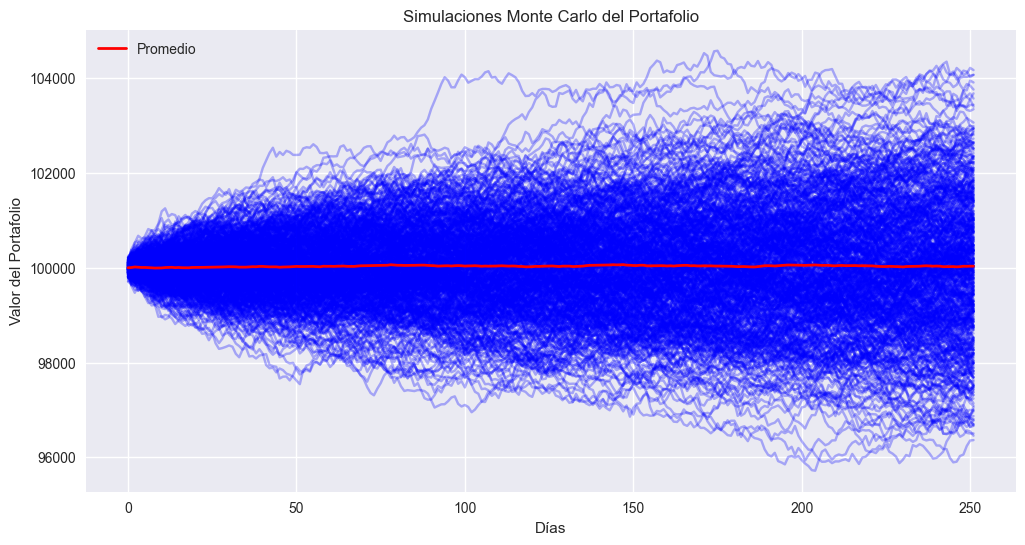

In [74]:
simulations = monte_carlo_simulation(weights, mean_returns, cov_matrix, start_value=100000, n_sim=500)

plt.figure(figsize=(12,6))
for sim in simulations:
    plt.plot(sim, alpha=0.3, color='blue')

avg_sim = np.mean(simulations, axis=0)
plt.plot(avg_sim, color='red', linewidth=2, label='Promedio')

plt.title('Simulaciones Monte Carlo del Portafolio')
plt.xlabel('Días')
plt.ylabel('Valor del Portafolio')
plt.legend()
plt.show()

In [76]:
def historical_var_cvar(returns_series: pd.Series, alpha: float = 0.05) -> Tuple[float, float]:
    sorted_losses = -returns_series.sort_values()
    var = sorted_losses.quantile(1-alpha)
    cvar = sorted_losses[sorted_losses >= var].mean()
    return var, cvar

In [77]:
import matplotlib.pyplot as plt

def plot_portfolio_pie(tickers, optimal_weights, title="Portfolio Allocation"):
    plt.figure(figsize=(8,8))
    plt.pie(optimal_weights, labels=tickers, autopct='%1.2f%%', startangle=90, colors=plt.cm.tab20.colors)
    plt.title(title, fontsize=14)
    plt.axis('equal')  # Mantiene el pie circular
    plt.show()

AAPL score 0.464
MSFT score 0.431
GOOGL score 0.482
AMZN score 0.372
Stats: {'return': np.float64(0.401760021291931), 'vol': np.float64(0.24543072259413332), 'sharpe': np.float64(1.4739801825469523)}


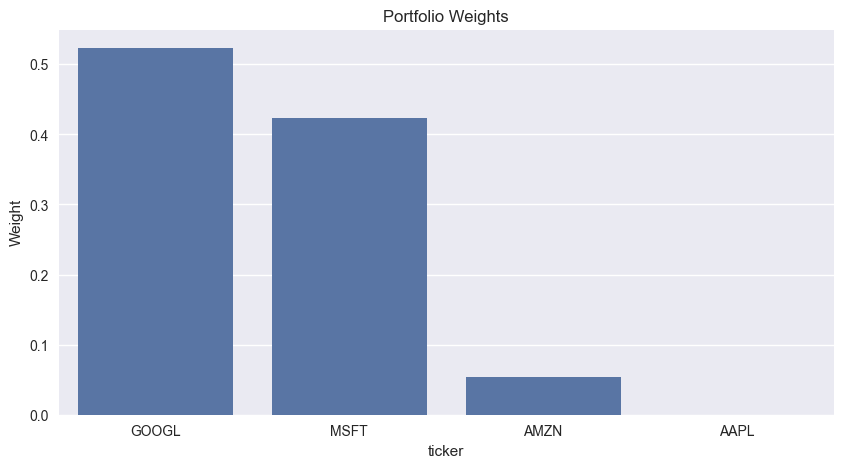

Monte Carlo final value percentiles:


ValueError: Data must be 1-dimensional, got ndarray of shape (50, 252) instead

In [71]:
tickers = DEFAULT_TICKERS  # o load_tickers_from_csv('mis_tickers.csv')
universe = build_universe_from_tickers(tickers, min_score=0.35, verbose=True)
prices, rets = prepare_price_returns(tickers)
# Filtrar rets sólo con tickers aptos:
apto_tickers = list(universe[universe['apto']].index)
prices_apto = prices[apto_tickers]
rets_apto = rets[apto_tickers]
if len(apto_tickers) >= 2:
    port = build_and_optimize_portfolio(universe, rets, method='max_sharpe')
    print("Stats:", port['stats'])
    plot_portfolio_weights(port['tickers'], port['weights'])
    mc = monte_carlo_simulation(port['weights'], rets[port['tickers']].mean().values, rets[port['tickers']].cov().values)
    print("Monte Carlo final value percentiles:")
    print(pd.Series(mc).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))
else:
    print("No hay suficientes activos aptos para construir un portafolio.")